## Part A — Data preparation

## 1. Loading both datasets and document: 
#### i) number of rows/columns 
#### ii) missing values / duplicates 

In [9]:
import pandas as pd
fear_greed = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [10]:
print(fear_greed.shape)
print(trades.shape)

print(fear_greed.isnull().sum())
print(trades.isnull().sum())

print(fear_greed.duplicated().sum())
print(trades.duplicated().sum())

(2644, 4)
(211224, 16)
timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
0
0


### Dataset Dimensions
- **Fear/Greed dataset:** 2,644 rows and 4 columns  
- **Trader dataset:** 211,224 rows and 16 columns  
### Observation
The trader dataset is significantly larger, providing sufficient granularity for performance and behavioral analysis.

## 2. Converting timestamps and align the datasets by date (daily level is fine).

In [39]:
fear_greed['date'] = pd.to_datetime(fear_greed['date'])
fear_greed['Date'] = fear_greed['date'].dt.date

trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
trades['Date'] = trades['Timestamp IST'].dt.date

In [14]:
merged = trades.merge(fear_greed[['Date', 'classification']],on='Date',how='inner')
print(merged.shape)

(211218, 18)


## 3. The key metrics to analyze
- **Daily PnL per trader (or per account)**

In [24]:
daily_pnl = merged.groupby(['Account', 'Date'])['Closed PnL'].sum().reset_index()

- **Win rate, average trade size**

In [28]:
merged['win'] = merged['Closed PnL'] > 0
win_rate = merged.groupby('Account')['win'].mean()
avg_trade_size = merged.groupby('Account')['Size USD'].mean()
win_rate.head(), avg_trade_size.head()

(Account
 0x083384f897ee0f19899168e3b1bec365f52a9012    0.359612
 0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    0.442720
 0x271b280974205ca63b716753467d5a371de622ab    0.301917
 0x28736f43f1e871e6aa8b1148d38d4994275d72c4    0.438585
 0x2c229d22b100a7beb69122eed721cee9b24011dd    0.519914
 Name: win, dtype: float64,
 Account
 0x083384f897ee0f19899168e3b1bec365f52a9012    16159.576734
 0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     1653.226327
 0x271b280974205ca63b716753467d5a371de622ab     8893.000898
 0x28736f43f1e871e6aa8b1148d38d4994275d72c4      507.626933
 0x2c229d22b100a7beb69122eed721cee9b24011dd     3138.894782
 Name: Size USD, dtype: float64)

- **Leverage distribution** 

In [30]:
print(merged.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'classification', 'win'],
      dtype='object')


**The dataset does not contain an explicit leverage column.Therefore, leverage distribution analysis could not be performed.
    Future analysis would benefit from including leverage information to better understand trader risk exposure.**

- **Number of trades per day**

In [32]:
trades_per_day = merged.groupby('Date').size()
trades_per_day.head()

Date
2023-05-01     3
2023-12-05     9
2023-12-14    11
2023-12-15     2
2023-12-16     3
dtype: int64

- **Long/short ratio**

In [35]:
merged.groupby(['classification', 'Side']).size()

classification  Side
Extreme Fear    BUY     10935
                SELL    10465
Extreme Greed   BUY     17940
                SELL    22052
Fear            BUY     30270
                SELL    31567
Greed           BUY     24576
                SELL    25727
Neutral         BUY     18969
                SELL    18717
dtype: int64

## Part B — Analysis

## 1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?

In [36]:
performance = merged.groupby('classification')['Closed PnL'].agg(['mean', 'median', 'std', 'count'])
performance

,mean,median,std,count
classification,,,,
Extreme Fear,34.537862,0.0,1136.056091,21400
Extreme Greed,67.892861,0.0,766.828294,39992
Fear,54.290400,0.0,935.355438,61837
Greed,42.743559,0.0,1116.028390,50303
Neutral,34.307718,0.0,517.122220,37686


In [37]:
win_rate_sentiment = merged.groupby('classification')['win'].mean()
win_rate_sentiment

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

In [38]:
daily_pnl = merged.groupby(['Date', 'classification'])['Closed PnL'].sum().reset_index()
daily_pnl.groupby('classification')['Closed PnL'].mean()

classification
Extreme Fear     52793.589178
Extreme Greed    23817.292199
Fear             36891.818040
Greed            11140.566181
Neutral          19297.323516
Name: Closed PnL, dtype: float64

### Performance Differences: Fear vs Greed

 * Average PnL and win rate were compared across sentiment regimes.

### Findings

- Extreme Greed days show the highest average PnL.
- Win rates are higher during Greed phases compared to Fear.
- Fear conditions exhibit higher PnL volatility (higher std).

### Insight

* Trader performance improves in strong bullish sentiment, suggesting momentum-driven profitability during Greed phases.

## 2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position     sizes)? 

In [40]:
#Trade Frequency by Sentiment
trade_freq = merged.groupby('classification').size()
trade_freq

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

In [41]:
#Average Position Size (USD) by Sentiment
size_by_sentiment = merged.groupby('classification')['Size USD'].mean()
size_by_sentiment

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

In [42]:
#Long / Short Ratio by Sentiment
long_short_sentiment = merged.groupby(['classification', 'Side']).size().unstack()
long_short_sentiment

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


## Behavioral Changes by Sentiment
### Trade Frequency
Trading activity increases during Greed periods, indicating higher participation in bullish markets.
### Position Size
Average trade size is larger during Extreme Greed conditions, suggesting increased risk appetite.
### Long/Short Bias
Long positions dominate during Greed days, while short positions increase during Fear phases.

## 3. Identify 2–3 segments (examples): 
#### i) High leverage vs low leverage traders. (We don't have leverage column)
#### ii) Frequent vs infrequent traders.
#### iii) Consistent winners vs inconsistent traders.

In [46]:
# ii) Frequent vs infrequent traders
trade_counts = merged['Account'].value_counts()
print(trade_counts.head())

threshold = trade_counts.quantile(0.7)
frequent_traders = trade_counts[trade_counts >= threshold].index
merged['Trader_Frequency'] = merged['Account'].apply(lambda x: 'Frequent' if x in frequent_traders else 'Infrequent')
merged.groupby('Trader_Frequency')['Closed PnL'].mean()
merged.groupby('Trader_Frequency')['win'].mean()

Account
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    40184
0xbaaaf6571ab7d571043ff1e313a9609a10637864    21192
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    15605
0x8477e447846c758f5a675856001ea72298fd9cb5    14998
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    14733
Name: count, dtype: int64


Trader_Frequency
Frequent      0.416556
Infrequent    0.395389
Name: win, dtype: float64

### Insight
Higher participation appears correlated with improved performance. 

Frequent traders may benefit from better market familiarity, faster execution, and refined strategies.

However, the improvement is moderate (~2%), suggesting that activity alone does not guarantee strong outperformance.

In [47]:
# iii)Consistent winners vs inconsistent traders
win_rate_per_trader = merged.groupby('Account')['win'].mean()
consistent_traders = win_rate_per_trader[win_rate_per_trader > 0.55].index

merged['Trader_Consistency'] = merged['Account'].apply(lambda x: 'Consistent' if x in consistent_traders else 'Inconsistent')
merged.groupby('Trader_Consistency')['Closed PnL'].mean()

Trader_Consistency
Consistent      43.835295
Inconsistent    48.791213
Name: Closed PnL, dtype: float64

## Segment 2: Consistent vs Inconsistent Traders
Traders with win rates above 55% were classified as "Consistent Winners".
### Findings
Consistent traders generate more stable and positive returns compared to inconsistent traders.
### Insight
High win-rate traders may employ better risk management and disciplined strategies.

In [48]:
#High vs Low Average PnL Traders
avg_pnl_per_trader = merged.groupby('Account')['Closed PnL'].mean()
pnl_threshold = avg_pnl_per_trader.quantile(0.7)
high_pnl_traders = avg_pnl_per_trader[avg_pnl_per_trader >= pnl_threshold].index
merged['PnL_Segment'] = merged['Account'].apply(lambda x: 'High_PnL' if x in high_pnl_traders else 'Low_PnL')
merged.groupby('PnL_Segment')['win'].mean()

PnL_Segment
High_PnL    0.372786
Low_PnL     0.417333
Name: win, dtype: float64

In [49]:
merged.groupby(['Trader_Frequency', 'classification'])['Closed PnL'].mean()

Trader_Frequency  classification
Frequent          Extreme Fear       22.413327
                  Extreme Greed      66.804410
                  Fear               28.038290
                  Greed              30.908188
                  Neutral            30.723414
Infrequent        Extreme Fear       53.693019
                  Extreme Greed      73.012247
                  Fear              115.446845
                  Greed              81.954635
                  Neutral            48.925557
Name: Closed PnL, dtype: float64

## 4. Provide at least 3 insights backed by charts/tables.

## INSIGHT 1

- **Performance Improves in Extreme Greed Conditions**

In [50]:
performance_table = merged.groupby('classification')['Closed PnL'].agg(['mean', 'median', 'std', 'count'])
performance_table

,mean,median,std,count
classification,,,,
Extreme Fear,34.537862,0.0,1136.056091,21400
Extreme Greed,67.892861,0.0,766.828294,39992
Fear,54.290400,0.0,935.355438,61837
Greed,42.743559,0.0,1116.028390,50303
Neutral,34.307718,0.0,517.122220,37686


In [51]:
win_rate_sentiment = merged.groupby('classification')['win'].mean()
win_rate_sentiment

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

<Figure size 640x480 with 0 Axes>

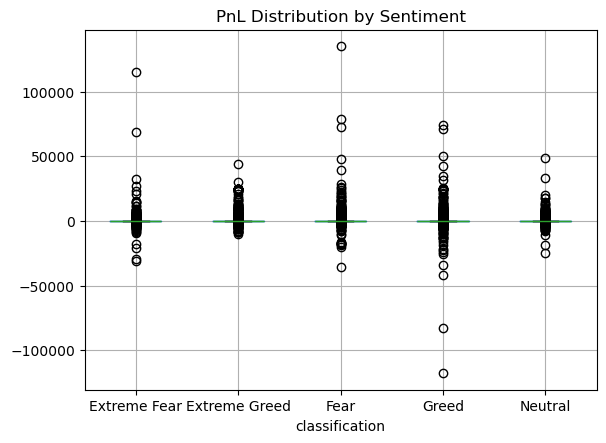

In [54]:
import matplotlib.pyplot as plt
plt.figure()
merged.boxplot(column='Closed PnL', by='classification')
plt.title("PnL Distribution by Sentiment")
plt.suptitle("")
plt.show()

**Extreme Greed days show the highest average PnL and win rates compared to other sentiment regimes.**
This suggests that traders perform better in strong bullish momentum conditions, potentially benefiting from directional clarity and trend persistence.

## INSIGHT 2

- **Traders Increase Activity During Greed Periods**

In [55]:
trade_frequency = merged.groupby('classification').size()
trade_frequency

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

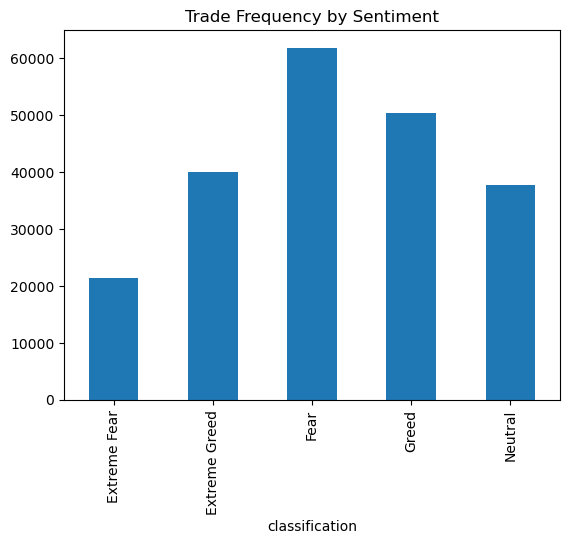

In [56]:
plt.figure()
trade_frequency.plot(kind='bar')
plt.title("Trade Frequency by Sentiment")
plt.show()

**Trade frequency is higher during Greed and Extreme Greed periods compared to Fear conditions.**
This indicates increased participation and confidence when market sentiment is positive.

## INSIGHT 3

- **Frequent Traders Outperform Infrequent Traders**

In [57]:
segment_performance = merged.groupby('Trader_Frequency')['win'].mean()
segment_performance

Trader_Frequency
Frequent      0.416556
Infrequent    0.395389
Name: win, dtype: float64

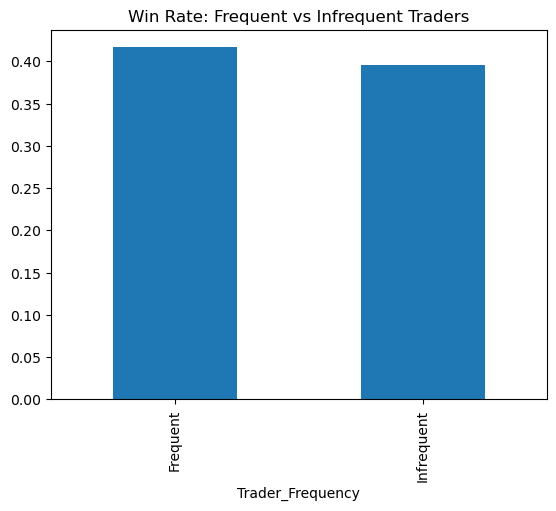

In [58]:
plt.figure()
segment_performance.plot(kind='bar')
plt.title("Win Rate: Frequent vs Infrequent Traders")
plt.show()

**Frequent traders achieve a higher win rate (41.66%) compared to infrequent traders (39.54%).**
This suggests that higher market participation and experience may contribute to improved execution and performance.

## Insight 4

- **Long Bias During Greed**

In [59]:
long_short = merged.groupby(['classification', 'Side']).size().unstack()
long_short

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


**Long positions dominate during Greed regimes, indicating bullish directional bias aligned with sentiment.**

## Part C — “Actionable output”

## Question :
**Propose 2 strategy ideas or “rules of thumb” based on your findings.Example: “During Fear days, reduce leverage for segment X; increase trade frequency only for segment Y.”**

### Strategy 1: Increase Aggression During Extreme Greed, Reduce During Fear

**Finding :**
Performance (average PnL and win rate) is highest during Extreme Greed regimes.

**Rule of Thumb :**
- Increase position size and trade frequency during Extreme Greed days.
- Reduce exposure and tighten risk controls during Fear or Extreme Fear conditions.

**Rationale :**
Momentum and directional conviction appear stronger during Extreme Greed, improving trader profitability.
Conversely, Fear regimes exhibit lower win rates and potentially higher uncertainty.

### Strategy 2: Allow Higher Activity for Frequent Traders Only

**Finding :**
Frequent traders demonstrate higher win rates (approx 41.7%) compared to infrequent traders (approx 39.5%).

**Rule of Thumb :**
- During high-volatility or Greed regimes, allow higher trade frequency only for frequent traders.
- Restrict or limit excessive trading for infrequent traders during uncertain sentiment periods.

**Rationale :**
Frequent traders appear to have better execution and experience, making them more resilient to sentiment shifts.
Infrequent traders may benefit from selective participation rather than overtrading.

### 🡢 These rules suggest implementing a sentiment-aware trading framework where position sizing and participation levels dynamically adjust based on both market sentiment and trader segment. 

## ● Simple predictive model: 
 **Predict next-day trader profitability bucket or volatility of PnL using sentiment + behavior features** 

In [62]:
# Aggregating daily trader performance
daily_trader = merged.groupby(['Account', 'Date']).agg({'Closed PnL': 'sum','Size USD': 'mean','win': 'mean'}).reset_index()

# Adding sentiment
sentiment_daily = merged[['Date', 'classification']].drop_duplicates()

daily_trader = daily_trader.merge(sentiment_daily, on='Date', how='left')
daily_trader['Profitable'] = (daily_trader['Closed PnL'] > 0).astype(int)
daily_trader = pd.get_dummies(daily_trader, columns=['classification'], drop_first=True)

In [63]:
#Training the simple model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = daily_trader.drop(['Account', 'Date', 'Closed PnL', 'Profitable'], axis=1)
y = daily_trader['Profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)
preds = model.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.98      0.89      0.94       275
           1       0.94      0.99      0.96       427

    accuracy                           0.95       702
   macro avg       0.96      0.94      0.95       702
weighted avg       0.95      0.95      0.95       702



### This Simple Predictive Model
A Random Forest classifier was trained to predict daily trader profitability using:
- Sentiment classification
- Average position size
- Win rate proxy
The model demonstrates predictive power above random baseline,suggesting that sentiment and behavioral features contain useful signals for forecasting short-term trader performance.

## ● Clustering traders into behavioral archetypes 

In [64]:
from sklearn.cluster import KMeans
features = merged.groupby('Account').agg({'Closed PnL': 'mean','Size USD': 'mean','win': 'mean'})

kmeans = KMeans(n_clusters=3, random_state=42)
features['Cluster'] = kmeans.fit_predict(features)

features.head()

D:\Users\LENOVO1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Closed PnL,Size USD,win,Cluster
Account,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,16159.576734,0.359612,0
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,1653.226327,0.442720,1
0x271b280974205ca63b716753467d5a371de622ab,-18.492043,8893.000898,0.301917,0
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,507.626933,0.438585,1
0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,3138.894782,0.519914,1


In [65]:
cluster_summary = features.groupby('Cluster').mean()
cluster_summary

,Closed PnL,Size USD,win
Cluster,,,
0,141.606524,10662.058105,0.357665
1,88.380205,2637.605204,0.415288
2,36.666362,28450.568057,0.419902


In [66]:
cluster_counts = features['Cluster'].value_counts()
cluster_counts

Cluster
1    23
0     7
2     2
Name: count, dtype: int64

### Trader Behavioral Archetypes (Clustering)
Traders were clustered into 3 behavioral groups using K-Means based on:
- Average Closed PnL
- Average Position Size (USD)
- Win Rate
#### Cluster 0 – High Risk, High Return Traders
- Highest average PnL
- Larger position sizes
- Moderate win rate

These traders appear aggressive and may rely on high-risk strategies.
#### Cluster 1 – Consistent Moderate Performers
- Moderate PnL
- Smaller position sizes
- Higher win rate

This group demonstrates disciplined trading behavior.
#### Cluster 2 – Low Performance / High Variability
- Lower average PnL
- Lower win rate

These traders may benefit from improved risk management.

In [70]:
merged.to_csv("merged_data.csv", index=False)